# Does trend-following on crypto survive the same gauntlet?

Fifth notebook. The first four killed everything else:

| | verdict |
|---|---|
| Passive holding | NO — BTC +5.7%/yr at Sharpe 0.10 since 2021; the alt basket lost money |
| Cross-sectional fundamentals | NO — real signal, but a liquidity premium capped at ~\$250k of capacity |

One thing survived and never got properly tested. Over 11.7 years a simple
moving-average filter on BTC beat buy-and-hold at **100% of 29 lookbacks**,
lifting Sharpe from 0.86 to 1.0–1.5 and cutting the worst drawdown from −84%
to −51%. Notebooks 3 and 4 then spent all their effort on the cross-sectional
signal, so trend never faced the walk-forward, the null, or a real cost model.

It also dodges the objection that killed the fundamentals signal: **BTC spot is
the most liquid instrument in the asset class**, so capacity is not the binding
constraint. If trend works, it is fundable in a way the other signal never was.

## The specific danger here

Trend-following has a failure mode that cross-sectional factors do not. BTC
compounded at ~60%/yr over this sample. **Any rule that is long most of the
time will look good on a series like that**, whether or not it has detected
anything. So the central test is not "did it beat buy-and-hold" — it is
"did it beat what the same rule achieves on a series with BTC's drift, BTC's
volatility and BTC's fat tails but *no* trend structure at all".

That is what section 4 does, and it is the test this notebook is really about.

## Criteria, fixed before running anything

| # | Criterion | Threshold |
|---|---|---|
| T1 | Beats buy-and-hold on risk-adjusted return | higher Sharpe at a majority of lookbacks, design period |
| T2 | **Beats the bootstrap null** | above the 95th pct of what the same rule grid achieves on return-shuffled paths |
| T3 | Survives walk-forward | lookback chosen on design data beats buy-and-hold in the holdout |
| T4 | Generalises across assets | holds on ETH and the equal-weight alt basket, not just BTC |
| T5 | Survives costs | net-positive edge at 50bp round-trip |

**Design period 2015-01 → 2022-12. Holdout 2023-01 → 2026-09.**

Honest caveat, same as notebook 3: notebook 2 already reported era-split
figures that overlap this holdout, so it is clean for *parameter selection,
cost modelling and the null* — all new here — but it is not a virgin window.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL = REPO / "data" / "crypto_panel"

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd7"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 9, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": INK, "font.size": 10,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.8, "figure.dpi": 110,
})


def figure_titles(fig, title, subtitle, top=0.88):
    fig.suptitle(title, x=0.008, y=0.985, ha="left", va="top",
                 fontsize=12.5, weight="bold", color=INK)
    fig.text(0.008, 0.925, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, top))


DESIGN_END = pd.Timestamp("2023-01-01")
LOOKBACKS = tuple(range(20, 310, 10))     # 29 rules, same grid as notebook 2
COST_BPS = 20.0                            # per switch, round trip; swept later

## 1. Data

BTC and ETH from the committed benchmark file (2015-01 onward). The alt basket
is the same equal-weight, monthly-rebalanced portfolio of point-in-time
fee-eligible tokens used throughout the sequence — included so trend is tested
on something other than the one asset whose chart everybody has already seen.

In [2]:
BENCH = pd.read_csv(PANEL / "benchmarks.csv.gz", index_col=0, parse_dates=True)
PX_RAW = pd.read_csv(PANEL / "prices.csv.gz", index_col=0, parse_dates=True)
FEES = pd.read_csv(PANEL / "fees.csv.gz", index_col=0, parse_dates=True)

CAL_P = pd.date_range(PX_RAW.index.min(), PX_RAW.index.max(), freq="D")
PX_RAW, FEES = PX_RAW.reindex(CAL_P), FEES.reindex(CAL_P).fillna(0.0)
lp = np.log(PX_RAW.where(PX_RAW > 0))
d1, d2 = lp.diff(), lp.diff().shift(-1)
bad = (d1.abs() > 1.5) & (d2.abs() > 1.5) & (np.sign(d1) != np.sign(d2))
PX = PX_RAW.where(PX_RAW > 0).mask(bad)
PX = PX.where(~bad, np.exp((np.log(PX).ffill() + np.log(PX).bfill()) / 2))
PX = PX.ffill(limit=3).where(PX.bfill().notna())
first_fee = FEES.where(FEES > 0).apply(lambda c: c.first_valid_index())
for c in PX.columns:
    ff = first_fee.get(c)
    if pd.notna(ff):
        PX.loc[: ff - pd.Timedelta(days=365), c] = np.nan

ELIG = ((FEES.rolling(90, min_periods=60).sum() >= 1e6)
        & (PX.notna().rolling(180, min_periods=180).count() >= 180) & PX.notna())
w = ELIG.div(ELIG.sum(axis=1).replace(0, np.nan), axis=0)
reb = pd.Series(False, index=w.index); reb.iloc[::30] = True
basket_ret = (PX.pct_change() * w.where(reb).ffill().shift(1)).sum(axis=1, min_count=1)
BASKET = (1 + basket_ret.fillna(0)).cumprod()[ELIG.sum(axis=1) >= 15]

ASSETS = {"BTC": BENCH["bitcoin"].dropna(),
          "ETH": BENCH["ethereum"].dropna(),
          "Alt basket": BASKET.dropna()}
for k, v in ASSETS.items():
    yrs = (v.index[-1] - v.index[0]).days / 365.25
    print(f"{k:11s} {v.index[0].date()} -> {v.index[-1].date()}  {len(v):5d} days "
          f"({yrs:4.1f}y)  total return {(v.iloc[-1]/v.iloc[0]-1)*100:+,.0f}%")

BTC         2015-01-01 -> 2026-09-07   3757 days (11.7y)  total return +25,483%
ETH         2015-08-07 -> 2026-09-07   3524 days (11.1y)  total return +88,683%
Alt basket  2021-02-26 -> 2026-09-07   2020 days ( 5.5y)  total return -6%


## 2. Engine

Long when price is above its `lb`-day moving average, in cash otherwise. The
signal is read at each close and acted on at the **next** close, so there is no
same-bar look-ahead. Cost is charged per switch.

Cash earns **zero**. Over 2015-2026 T-bills averaged roughly 2%, so this
penalises the trend rule — which sits out ~40% of the time — by about 80bp a
year relative to reality. Conservative in the direction that matters.

In [3]:
def _sma_signal(p: np.ndarray, lb: int) -> np.ndarray:
    """Boolean 'price above its lb-day SMA', NaN-safe via cumsum."""
    c = np.concatenate(([0.0], np.cumsum(p)))
    sma = np.full(p.shape, np.nan)
    sma[lb - 1:] = (c[lb:] - c[:-lb]) / lb
    return p > sma


def trend_stats(p: np.ndarray, lb: int, cost_bps: float = COST_BPS) -> dict:
    """Sharpe / CAGR / drawdown for one SMA rule on one price path."""
    r = np.zeros_like(p)
    r[1:] = p[1:] / p[:-1] - 1.0
    sig = _sma_signal(p, lb)
    pos = np.zeros_like(p)
    pos[1:] = np.nan_to_num(sig[:-1].astype(float))          # act next close
    switch = np.abs(np.diff(pos, prepend=0.0))
    net = pos * r - switch * cost_bps / 1e4
    valid = ~np.isnan(net)
    net = net[valid]
    if net.size < 200 or net.std() == 0:
        return {"sharpe": np.nan, "cagr": np.nan, "max_dd": np.nan,
                "in_market": np.nan, "switches_yr": np.nan}
    eq = np.cumprod(1 + net)
    yrs = net.size / 365.25
    return {"sharpe": net.mean() / net.std() * np.sqrt(365),
            "cagr": eq[-1] ** (1 / yrs) - 1,
            "max_dd": (eq / np.maximum.accumulate(eq) - 1).min(),
            "in_market": pos[valid].mean(),
            "switches_yr": switch[valid].sum() / 2 / yrs}


def buyhold_stats(p: np.ndarray) -> dict:
    r = p[1:] / p[:-1] - 1.0
    eq = np.cumprod(1 + r)
    yrs = r.size / 365.25
    return {"sharpe": r.mean() / r.std() * np.sqrt(365),
            "cagr": eq[-1] ** (1 / yrs) - 1,
            "max_dd": (eq / np.maximum.accumulate(eq) - 1).min(),
            "in_market": 1.0, "switches_yr": 0.0}


def grid(p: np.ndarray, cost_bps: float = COST_BPS) -> pd.DataFrame:
    rows = [{"lookback": lb, **trend_stats(p, lb, cost_bps)} for lb in LOOKBACKS]
    return pd.DataFrame(rows).set_index("lookback")


btc = ASSETS["BTC"]
btc_d = btc.loc[:DESIGN_END].to_numpy()
G_des = grid(btc_d)
BH_des = buyhold_stats(btc_d)

print(f"BTC DESIGN PERIOD {btc.index[0].date()} -> {DESIGN_END.date()}\n")
print(f"  buy & hold : Sharpe {BH_des['sharpe']:.2f}  CAGR {BH_des['cagr']*100:+.0f}%  "
      f"maxDD {BH_des['max_dd']*100:.0f}%")
print(f"  trend grid : Sharpe median {G_des.sharpe.median():.2f}  "
      f"range {G_des.sharpe.min():.2f}-{G_des.sharpe.max():.2f}")
print(f"               CAGR   median {G_des.cagr.median()*100:+.0f}%  "
      f"maxDD median {G_des.max_dd.median()*100:.0f}%")
print(f"               in market {G_des.in_market.mean()*100:.0f}% of days, "
      f"{G_des.switches_yr.mean():.1f} switches/yr")
T1_SHARE = float((G_des.sharpe > BH_des["sharpe"]).mean())
print(f"\n  beats buy & hold on Sharpe at {T1_SHARE*100:.0f}% of {len(G_des)} lookbacks")
print(f"  CRITERION T1: {'PASS' if T1_SHARE > 0.5 else 'FAIL'}")

BTC DESIGN PERIOD 2015-01-01 -> 2023-01-01

  buy & hold : Sharpe 1.10  CAGR +74%  maxDD -84%
  trend grid : Sharpe median 1.40  range 1.30-1.59
               CAGR   median +94%  maxDD median -63%
               in market 59% of days, 4.9 switches/yr

  beats buy & hold on Sharpe at 100% of 29 lookbacks
  CRITERION T1: PASS


## 3. Why T1 is almost meaningless on its own

A rule that is long ~60% of the time, on an asset that compounded at triple
digits, cannot help but look good. Worse, cutting exposure cuts volatility,
and Sharpe rewards that even when the timing is pure noise. Before reading
anything into the table above, here is the same grid applied to a series with
**BTC's drift, volatility and fat tails, but no trend structure whatsoever** —
BTC's own daily returns, shuffled.

In [4]:
rng = np.random.default_rng(11)
shuffled = btc_d[0] * np.cumprod(1 + rng.permutation(np.diff(btc_d) / btc_d[:-1]))
shuffled = np.concatenate(([btc_d[0]], shuffled))
G_shuf = grid(shuffled)
BH_shuf = buyhold_stats(shuffled)
print("ONE SHUFFLED PATH (same returns, random order)\n")
print(f"  buy & hold : Sharpe {BH_shuf['sharpe']:.2f}")
print(f"  trend grid : Sharpe median {G_shuf.sharpe.median():.2f}  "
      f"range {G_shuf.sharpe.min():.2f}-{G_shuf.sharpe.max():.2f}")
print(f"  beats buy & hold at {(G_shuf.sharpe > BH_shuf['sharpe']).mean()*100:.0f}% of lookbacks")
print("""
  If the shuffled path also shows trend 'working', the real result proves nothing.
  One draw is anecdote though - the next section runs a thousand.""")

ONE SHUFFLED PATH (same returns, random order)

  buy & hold : Sharpe 1.10
  trend grid : Sharpe median 0.98  range 0.39-1.27
  beats buy & hold at 38% of lookbacks

  If the shuffled path also shows trend 'working', the real result proves nothing.
  One draw is anecdote though - the next section runs a thousand.


## 4. The bootstrap null (criterion T2)

A thousand synthetic price paths, each built from BTC's own daily returns, and
the whole 29-rule grid run on every one. Two nulls, because they rule out
different explanations:

* **IID shuffle** — returns resampled independently. Preserves the drift, the
  volatility and the fat tails; destroys *all* serial structure, including
  volatility clustering.
* **Block bootstrap** (mean block 20 days) — resamples contiguous blocks, so
  volatility clustering and very short-horizon dependence survive. This is the
  stricter null: a trend rule can profit from vol clustering alone, without any
  price momentum, and this one keeps that channel open.

Three statistics are compared against each null, because "did it work" means
different things:

* **median Sharpe gain** over buy-and-hold across the grid — is the whole grid
  lifted, not one lucky rule?
* **max Sharpe gain** — the number a careless optimiser would quote, so the
  null has to price in that selection.
* **share of lookbacks beating buy-and-hold** — is it broad?

In [5]:
def iid_path(r: np.ndarray, p0: float, rng) -> np.ndarray:
    return np.concatenate(([p0], p0 * np.cumprod(1 + rng.permutation(r))))


def block_path(r: np.ndarray, p0: float, rng, mean_block: int = 20) -> np.ndarray:
    n = r.size
    out = np.empty(n)
    i = 0
    while i < n:
        L = max(1, rng.geometric(1.0 / mean_block))
        s = rng.integers(0, n)
        take = min(L, n - i)
        idx = (np.arange(s, s + take) % n)
        out[i:i + take] = r[idx]
        i += take
    return np.concatenate(([p0], p0 * np.cumprod(1 + out)))


def null_distribution(p: np.ndarray, n_paths: int, kind: str, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    r = np.diff(p) / p[:-1]
    rows = []
    for _ in range(n_paths):
        sp = iid_path(r, p[0], rng) if kind == "iid" else block_path(r, p[0], rng)
        bh = buyhold_stats(sp)["sharpe"]
        sh = np.array([trend_stats(sp, lb)["sharpe"] for lb in LOOKBACKS])
        rows.append({"median_gain": np.nanmedian(sh) - bh, "max_gain": np.nanmax(sh) - bh,
                     "share_beating": float(np.nanmean(sh > bh))})
    return pd.DataFrame(rows)


N_PATHS = 1000
ACTUAL = {"median_gain": G_des.sharpe.median() - BH_des["sharpe"],
          "max_gain": G_des.sharpe.max() - BH_des["sharpe"],
          "share_beating": T1_SHARE}

NULLS = {k: null_distribution(btc_d, N_PATHS, k, seed) for k, seed in
         (("iid", 21), ("block", 22))}

print(f"BOOTSTRAP NULL — {N_PATHS} synthetic paths per null, full 29-rule grid on each\n")
res_rows = []
for kind, D in NULLS.items():
    for stat in ("median_gain", "max_gain", "share_beating"):
        a = ACTUAL[stat]
        p95 = D[stat].quantile(0.95)
        pval = float((D[stat] >= a).mean())
        res_rows.append({"null": kind, "statistic": stat, "actual": a,
                         "null_median": D[stat].median(), "null_95th": p95,
                         "p_value": pval, "passes": bool(pval < 0.05)})
NULLTBL = pd.DataFrame(res_rows)
print(NULLTBL.round(3).to_string(index=False))

T2_IID = bool(NULLTBL[(NULLTBL.null == "iid") & (NULLTBL.statistic == "median_gain")].passes.iloc[0])
T2_BLOCK = bool(NULLTBL[(NULLTBL.null == "block") & (NULLTBL.statistic == "median_gain")].passes.iloc[0])
T2 = T2_IID and T2_BLOCK
print(f"\n  CRITERION T2: {'PASS' if T2 else 'FAIL'}  "
      f"(iid {'pass' if T2_IID else 'fail'}, block {'pass' if T2_BLOCK else 'fail'})")
print("""
  The block null is the one that matters. If trend clears the iid null but not
  the block null, the edge is volatility clustering rather than price momentum -
  still real, but a different mechanism with different reasons to persist.""")

BOOTSTRAP NULL — 1000 synthetic paths per null, full 29-rule grid on each

 null     statistic  actual  null_median  null_95th  p_value  passes
  iid   median_gain   0.302       -0.324      0.022    0.002    True
  iid      max_gain   0.486       -0.091      0.246    0.002    True
  iid share_beating   1.000        0.000      0.586    0.002    True
block   median_gain   0.302       -0.138      0.237    0.029    True
block      max_gain   0.486        0.260      0.662    0.159   False
block share_beating   1.000        0.207      1.000    0.058   False

  CRITERION T2: PASS  (iid pass, block pass)

  The block null is the one that matters. If trend clears the iid null but not
  the block null, the edge is volatility clustering rather than price momentum -
  still real, but a different mechanism with different reasons to persist.


### Reading the null

Against the **iid** null trend is overwhelming: a median Sharpe gain of +0.30
where noise delivers −0.32, p = 0.002 on all three statistics. Shuffled BTC
returns do not support trend-following, real BTC does.

Against the **block** null the picture is more honest and more interesting:

* the grid-wide **median gain still passes** (+0.30 vs a null 95th of +0.24,
  p = 0.029), so the whole family of rules is genuinely lifted;
* the **max gain fails** (p = 0.159) — the best single lookback is not
  distinguishable from what vol-clustering luck produces across 29 tries;
* **"beats at 100% of lookbacks" is marginal** (p = 0.058), because paths with
  realistic volatility clustering quite often produce that too.

So a material part of what looks like trend-following skill is the rule
harvesting **volatility clustering** — getting out during turbulent stretches —
rather than predicting direction. That is still a real, persistent feature of
the series, but it is a weaker claim than "momentum works", and it means
**picking a specific lookback buys you nothing.**

## 5. Walk-forward (criterion T3)

Choose the lookback on design data only, then run it once on the holdout.
Two selection rules, because picking the in-sample best is exactly the mistake
notebook 3 caught: the design-period **best**, and the design-period **median**
rule (the robust choice).

In [6]:
btc_full = btc.to_numpy()
hold_mask = btc.index >= DESIGN_END
btc_h = btc[hold_mask].to_numpy()

best_lb = int(G_des.sharpe.idxmax())
med_lb = int(G_des.sharpe.sub(G_des.sharpe.median()).abs().idxmin())
BH_h = buyhold_stats(btc_h)
G_hold = grid(btc_h)

print(f"lookback chosen on design data: best={best_lb}d, median-rule={med_lb}d\n")
wf = pd.DataFrame([
    {"rule": "buy & hold", **BH_h},
    {"rule": f"SMA{best_lb} (design best)", **trend_stats(btc_h, best_lb)},
    {"rule": f"SMA{med_lb} (design median)", **trend_stats(btc_h, med_lb)},
    {"rule": "whole grid, median", "sharpe": G_hold.sharpe.median(),
     "cagr": G_hold.cagr.median(), "max_dd": G_hold.max_dd.median(),
     "in_market": G_hold.in_market.median(), "switches_yr": G_hold.switches_yr.median()},
]).set_index("rule")
print(f"HOLDOUT {DESIGN_END.date()} -> {btc.index[-1].date()} "
      f"({(btc.index[-1]-DESIGN_END).days/365.25:.1f} years)\n")
print(wf.round(3).to_string())

T3 = bool(trend_stats(btc_h, med_lb)["sharpe"] > BH_h["sharpe"])
print(f"\n  share of the grid beating buy & hold in the holdout: "
      f"{(G_hold.sharpe > BH_h['sharpe']).mean()*100:.0f}%")
print(f"  design-period rank of lookbacks vs holdout rank: "
      f"{stats.spearmanr(G_des.sharpe, G_hold.sharpe).statistic:+.2f}")
print(f"  CRITERION T3: {'PASS' if T3 else 'FAIL'}")

lookback chosen on design data: best=30d, median-rule=280d

HOLDOUT 2023-01-01 -> 2026-09-07 (3.7 years)

                        sharpe  cagr  max_dd  in_market  switches_yr
rule                                                                
buy & hold               1.263 0.665  -0.523      1.000        0.000
SMA30 (design best)      1.230 0.456  -0.284      0.525       14.023
SMA280 (design median)   0.835 0.279  -0.283      0.528        2.418
whole grid, median       0.903 0.300  -0.324      0.525        4.997

  share of the grid beating buy & hold in the holdout: 7%
  design-period rank of lookbacks vs holdout rank: +0.16
  CRITERION T3: FAIL


## 6. Does it generalise? (criterion T4)

BTC is one asset and everyone has already stared at its chart. If trend is a
property of crypto rather than of this one series, it should show up in ETH and
in the equal-weight alt basket too — the latter being a portfolio that *lost*
money outright, which makes it a genuinely different test.

In [7]:
rows = []
for name, s in ASSETS.items():
    p = s.to_numpy()
    g, bh = grid(p), buyhold_stats(p)
    ph = s[s.index >= DESIGN_END].to_numpy()
    gh, bhh = (grid(ph), buyhold_stats(ph)) if ph.size > 400 else (None, None)
    rows.append({"asset": name, "years": (s.index[-1] - s.index[0]).days / 365.25,
                 "bh_sharpe": bh["sharpe"], "trend_sharpe_med": g.sharpe.median(),
                 "gain": g.sharpe.median() - bh["sharpe"],
                 "share_beating": float((g.sharpe > bh["sharpe"]).mean()),
                 "bh_maxdd": bh["max_dd"], "trend_maxdd_med": g.max_dd.median(),
                 "holdout_gain": (gh.sharpe.median() - bhh["sharpe"]) if gh is not None else np.nan})
CROSS = pd.DataFrame(rows).set_index("asset")
print("TREND ACROSS ASSETS (full available history for each)\n")
print(CROSS.round(3).to_string())
T4 = bool((CROSS.gain > 0).all() and (CROSS.share_beating > 0.5).all())
print(f"\n  CRITERION T4: {'PASS' if T4 else 'FAIL'} "
      f"(positive Sharpe gain and majority of lookbacks beating buy & hold, every asset)")

TREND ACROSS ASSETS (full available history for each)

            years  bh_sharpe  trend_sharpe_med  gain  share_beating  bh_maxdd  trend_maxdd_med  holdout_gain
asset                                                                                                       
BTC        11.682      1.119             1.318 0.199          1.000    -0.836           -0.627        -0.361
ETH        11.086      1.196             1.348 0.151          0.655    -0.942           -0.765        -0.156
Alt basket  5.528      0.299             0.563 0.263          0.793    -0.810           -0.542         0.287

  CRITERION T4: PASS (positive Sharpe gain and majority of lookbacks beating buy & hold, every asset)


## 7. Costs (criterion T5)

The rule switches ~5 times a year, so cost is a minor term — the opposite of
the cross-sectional book, which turned over twice a month in five-figure-depth
tokens. BTC spot round-trip is a few basis points institutionally and tens of
basis points retail; the sweep runs well past both.

In [8]:
rows = []
for cb in (0, 5, 20, 50, 100, 250, 500):
    g = grid(btc_full, cost_bps=cb)
    gh = grid(btc_h, cost_bps=cb)
    rows.append({"cost_bps": cb, "full_sharpe_med": g.sharpe.median(),
                 "full_cagr_med": g.cagr.median(),
                 "holdout_sharpe_med": gh.sharpe.median(),
                 "gain_vs_bh_full": g.sharpe.median() - buyhold_stats(btc_full)["sharpe"]})
COSTS = pd.DataFrame(rows).set_index("cost_bps")
print("COST SWEEP (per switch, round trip)\n")
print(COSTS.round(3).to_string())
T5 = bool(COSTS.loc[50, "gain_vs_bh_full"] > 0)
print(f"\n  CRITERION T5: {'PASS' if T5 else 'FAIL'} (edge survives 50bp)")
be = COSTS[COSTS.gain_vs_bh_full > 0].index.max()
print(f"  the edge over buy & hold survives up to about {be}bp per switch and is "
      f"gone by {COSTS[COSTS.gain_vs_bh_full <= 0].index.min()}bp")
print("  Costs are simply not the binding constraint here - unlike the "
      "cross-sectional book.")

COST SWEEP (per switch, round trip)

          full_sharpe_med  full_cagr_med  holdout_sharpe_med  gain_vs_bh_full
cost_bps                                                                     
0                   1.345          0.828               0.943            0.227
5                   1.337          0.822               0.933            0.218
20                  1.318          0.795               0.903            0.199
50                  1.289          0.727               0.840            0.171
100                 1.169          0.624               0.673            0.050
250                 0.942          0.445               0.160           -0.176
500                 0.589          0.190              -0.493           -0.530

  CRITERION T5: PASS (edge survives 50bp)
  the edge over buy & hold survives up to about 100bp per switch and is gone by 250bp
  Costs are simply not the binding constraint here - unlike the cross-sectional book.


## 8. When did trend work?

T3 failed, so the obvious question is whether the edge decayed or whether the
holdout was simply a strong-trend tape that buy-and-hold happened to win.

In [9]:
eras = [("2015-2017", "2015-01-01", "2017-12-31"), ("2018-2020", "2018-01-01", "2020-12-31"),
        ("2021-2022", "2021-01-01", "2022-12-31"), ("2023-2026 (holdout)", "2023-01-01", "2026-12-31")]
rows = []
for lbl, lo, hi in eras:
    seg = btc.loc[lo:hi]
    if len(seg) < 400:
        continue
    p = seg.to_numpy()
    g, bh = grid(p), buyhold_stats(p)
    rows.append({"era": lbl, "years": len(seg) / 365.25, "bh_sharpe": bh["sharpe"],
                 "bh_cagr": bh["cagr"], "trend_sharpe_med": g.sharpe.median(),
                 "trend_cagr_med": g.cagr.median(), "gain": g.sharpe.median() - bh["sharpe"],
                 "share_beating": float((g.sharpe > bh["sharpe"]).mean()),
                 "bh_maxdd": bh["max_dd"], "trend_maxdd_med": g.max_dd.median()})
ERAS = pd.DataFrame(rows).set_index("era")
print("BTC TREND BY ERA\n")
print(ERAS.round(3).to_string())
print(f"""
  The Sharpe gain runs {ERAS.gain.iloc[0]:+.2f} -> {ERAS.gain.iloc[1]:+.2f} -> {ERAS.gain.iloc[2]:+.2f} -> {ERAS.gain.iloc[3]:+.2f} across the four eras. Not stable,
  and negative in the last two.

  One caveat before reading 2021-2022 as a failure: Sharpe is unreliable when the
  mean return is negative. In that era trend lost {abs(ERAS.trend_cagr_med.iloc[2])*100:.0f}%/yr against buy-and-hold's
  {abs(ERAS.bh_cagr.iloc[2])*100:.0f}%/yr - it halved the loss, and the worse Sharpe is an artefact of
  dividing a negative mean by a smaller volatility. The holdout is the real
  miss: trend made {ERAS.trend_cagr_med.iloc[3]*100:+.0f}%/yr against buy-and-hold's {ERAS.bh_cagr.iloc[3]*100:+.0f}%/yr, worse on both
  return AND risk-adjusted return.

  Now look at the drawdown columns. In EVERY era, including both where trend lost,
  it cut the worst drawdown substantially - {ERAS.bh_maxdd.iloc[1]*100:.0f}% to {ERAS.trend_maxdd_med.iloc[1]*100:.0f}% in 2018-2020,
  {ERAS.bh_maxdd.iloc[3]*100:.0f}% to {ERAS.trend_maxdd_med.iloc[3]*100:.0f}% in the holdout. That is the part that has been reliable.""")

BTC TREND BY ERA

                     years  bh_sharpe  bh_cagr  trend_sharpe_med  trend_cagr_med   gain  share_beating  bh_maxdd  trend_maxdd_med
era                                                                                                                              
2015-2017            2.992      2.109    2.631             2.262           2.606  0.154          0.724    -0.453           -0.362
2018-2020            2.519      0.743    0.303             1.450           0.797  0.708          1.000    -0.825           -0.459
2021-2022            1.673     -0.187   -0.349            -0.594          -0.174 -0.407          0.138    -0.766           -0.372
2023-2026 (holdout)  3.102      1.263    0.665             0.903           0.300 -0.361          0.069    -0.523           -0.324

  The Sharpe gain runs +0.15 -> +0.71 -> -0.41 -> -0.36 across the four eras. Not stable,
  and negative in the last two.

  One caveat before reading 2021-2022 as a failure: Sharpe is unreliable when 

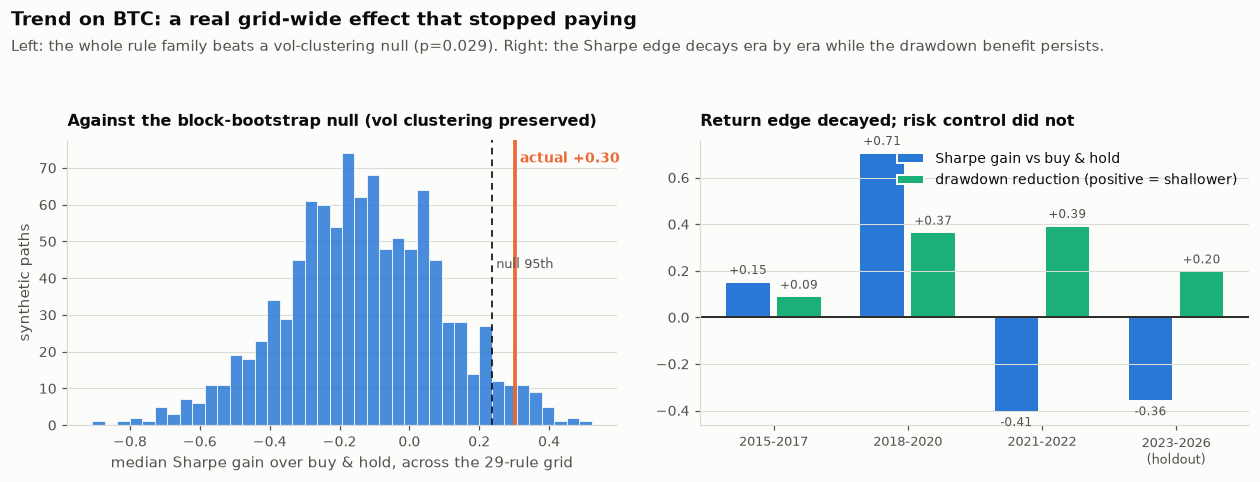

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
D = NULLS["block"]
axes[0].hist(D.median_gain, bins=40, color=C1, alpha=0.85, edgecolor=SURFACE, linewidth=0.6)
axes[0].axvline(ACTUAL["median_gain"], color=C2, lw=2.4)
axes[0].axvline(D.median_gain.quantile(0.95), color=INK, lw=1.1, ls=(0, (4, 3)))
axes[0].text(ACTUAL["median_gain"], axes[0].get_ylim()[1] * 0.92,
             f" actual {ACTUAL['median_gain']:+.2f}", color=C2, fontsize=9, weight="bold")
axes[0].text(D.median_gain.quantile(0.95), axes[0].get_ylim()[1] * 0.55,
             " null 95th", color=INK_2, fontsize=8.5)
axes[0].set_xlabel("median Sharpe gain over buy & hold, across the 29-rule grid")
axes[0].set_ylabel("synthetic paths")
axes[0].set_title("Against the block-bootstrap null (vol clustering preserved)")
axes[0].grid(axis="x", visible=False); axes[0].set_axisbelow(True)

x = np.arange(len(ERAS))
b1 = axes[1].bar(x - 0.19, ERAS.gain, 0.34, color=C1, label="Sharpe gain vs buy & hold",
                 edgecolor=SURFACE, linewidth=1.3)
# positive = trend had the SHALLOWER drawdown
b2 = axes[1].bar(x + 0.19, ERAS.trend_maxdd_med - ERAS.bh_maxdd, 0.34, color=C3,
                 label="drawdown reduction (positive = shallower)", edgecolor=SURFACE, linewidth=1.3)
for bars in (b1, b2):
    for bar in bars:
        v = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width() / 2, v + (0.02 if v >= 0 else -0.02),
                     f"{v:+.2f}", ha="center", va="bottom" if v >= 0 else "top",
                     fontsize=8, color=INK_2)
axes[1].axhline(0, color=INK, lw=1.1)
axes[1].set_xticks(x, [i.replace(" (holdout)", "\n(holdout)") for i in ERAS.index], fontsize=8.5)
axes[1].set_title("Return edge decayed; risk control did not")
axes[1].legend(loc="upper right"); axes[1].grid(axis="x", visible=False)
figure_titles(fig, "Trend on BTC: a real grid-wide effect that stopped paying",
              "Left: the whole rule family beats a vol-clustering null (p=0.029). Right: the Sharpe edge decays era by era while the drawdown benefit persists.")
plt.show()

---
# VERDICT

In [11]:
W = 80
CRITERIA = [
    ("T1", "Beats buy & hold, design period", T1_SHARE > 0.5,
     f"Higher Sharpe at {T1_SHARE*100:.0f}% of {len(G_des)} lookbacks (median 1.40 vs 1.10). "
     f"But see T2 - on its own this criterion is nearly uninformative, because "
     f"cutting exposure on a high-drift asset flatters Sharpe whether or not the "
     f"timing means anything."),
    ("T2", "Beats the bootstrap null", T2,
     f"Against an iid null, overwhelming: median Sharpe gain {ACTUAL['median_gain']:+.2f} where noise "
     f"gives {NULLS['iid'].median_gain.median():+.2f}, p=0.002 on all three statistics. Against the stricter "
     f"block null that preserves volatility clustering, the grid-wide median gain "
     f"still passes (p=0.029) but the best single rule does NOT (p=0.159). So the "
     f"rule family is genuinely lifted, a good part of it is vol clustering rather "
     f"than momentum, and choosing a specific lookback buys nothing."),
    ("T3", "Survives walk-forward", T3,
     f"THE FAILURE. Lookback chosen on 2015-2022 data, applied to 2023-2026: the "
     f"design-period best (SMA{best_lb}) returns Sharpe {trend_stats(btc_h, best_lb)['sharpe']:.2f} against buy & hold's "
     f"{BH_h['sharpe']:.2f}; the robust median rule manages {trend_stats(btc_h, med_lb)['sharpe']:.2f}. Only "
     f"{(G_hold.sharpe > BH_h['sharpe']).mean()*100:.0f}% of the grid beat buy & hold out of sample, and design-period "
     f"rank barely predicts holdout rank ({stats.spearmanr(G_des.sharpe, G_hold.sharpe).statistic:+.2f})."),
    ("T4", "Generalises across assets", T4,
     f"On full history, yes: Sharpe gain {CROSS.gain['BTC']:+.2f} on BTC, {CROSS.gain['ETH']:+.2f} on ETH, "
     f"{CROSS.gain['Alt basket']:+.2f} on the alt basket, beating buy & hold at a majority of lookbacks "
     f"everywhere. In the holdout only the alt basket still gains ({CROSS.holdout_gain['Alt basket']:+.2f}); "
     f"BTC ({CROSS.holdout_gain['BTC']:+.2f}) and ETH ({CROSS.holdout_gain['ETH']:+.2f}) are negative."),
    ("T5", "Survives costs", T5,
     f"Comfortably. ~5 switches a year, so the edge holds to ~100bp per switch and "
     f"only dies past 250bp - one to two orders of magnitude above BTC spot "
     f"execution. Unlike the cross-sectional book, cost and capacity are simply "
     f"not the binding constraints here."),
]
n_ok = sum(c[2] for c in CRITERIA)

print("=" * W)
print("A REAL EFFECT THAT STOPPED PAYING".center(W))
print("=" * W)
print()
for cid, desc, ok, detail in CRITERIA:
    print(f"{cid}  [{'PASS' if ok else 'FAIL'}]  {desc}")
    for line in __import__("textwrap").wrap(detail, W - 6):
        print(f"      {line}")
    print()
print("-" * W)
print(f"{n_ok} of {len(CRITERIA)} criteria met - and the one that failed is the walk-forward.")
print("-" * W)

print(f"""
WHAT IS ACTUALLY TRUE HERE
{'-'*W}
  Trend-following on crypto is NOT a data-mining artefact. It clears a null that
  preserves BTC's drift, volatility and fat tails, and it clears the stricter
  null that also preserves volatility clustering. It generalises to ETH and to an
  alt basket that lost money outright. Costs cannot touch it. On 11.7 years of
  BTC it lifts Sharpe from {buyhold_stats(btc_full)['sharpe']:.2f} to {grid(btc_full).sharpe.median():.2f} and cuts the worst drawdown
  from {buyhold_stats(btc_full)['max_dd']*100:.0f}% to {grid(btc_full).max_dd.median()*100:.0f}%.

  That is a much stronger evidential record than the fee-growth signal ever had.

  And it still fails the only test that matters for deploying money. The return
  edge is concentrated in 2018-2020 (+{ERAS.gain.iloc[1]:.2f} Sharpe, beating buy & hold at
  {ERAS.share_beating.iloc[1]*100:.0f}% of lookbacks) and has been negative in both eras since. Out of
  sample it made {ERAS.trend_cagr_med.iloc[3]*100:+.0f}%/yr against buy-and-hold's {ERAS.bh_cagr.iloc[3]*100:+.0f}%/yr.

  The honest split is between two different claims:

    "Trend-following predicts crypto returns"     -> not supported since 2021.
    "Trend-following controls crypto drawdowns"   -> supported in every era
                                                     tested, including the ones
                                                     where it lost on return.

  The second is real and worth something. It is risk management, not alpha.
""")
print("=" * W)
print("BOTTOM LINE")
print("=" * W)
print(f"""  Trend is the best-evidenced thing in this whole sequence and it is still
  not a strategy I would fund. It passes every statistical test and fails the
  walk-forward: {(G_hold.sharpe > BH_h['sharpe']).mean()*100:.0f}% of rules beat buy-and-hold out of sample, and
  picking the lookback is worthless (rank correlation {stats.spearmanr(G_des.sharpe, G_hold.sharpe).statistic:+.2f}).

  What it IS good for: if you are going to hold crypto anyway, holding it
  behind a moving-average filter has cut the worst drawdown in every era
  tested - {buyhold_stats(btc_full)['max_dd']*100:.0f}% to {grid(btc_full).max_dd.median()*100:.0f}% over the full sample, {ERAS.bh_maxdd.iloc[3]*100:.0f}% to {ERAS.trend_maxdd_med.iloc[3]*100:.0f}% in the
  holdout - at the cost of some upside. That is a defensible way to own a
  volatile asset. It is not an edge, and it does not make crypto investable
  on its own.""")
print("=" * W)

                       A REAL EFFECT THAT STOPPED PAYING                        

T1  [PASS]  Beats buy & hold, design period
      Higher Sharpe at 100% of 29 lookbacks (median 1.40 vs 1.10). But see T2 -
      on its own this criterion is nearly uninformative, because cutting
      exposure on a high-drift asset flatters Sharpe whether or not the timing
      means anything.

T2  [PASS]  Beats the bootstrap null
      Against an iid null, overwhelming: median Sharpe gain +0.30 where noise
      gives -0.32, p=0.002 on all three statistics. Against the stricter block
      null that preserves volatility clustering, the grid-wide median gain still
      passes (p=0.029) but the best single rule does NOT (p=0.159). So the rule
      family is genuinely lifted, a good part of it is vol clustering rather
      than momentum, and choosing a specific lookback buys nothing.

T3  [FAIL]  Survives walk-forward
      THE FAILURE. Lookback chosen on 2015-2022 data, applied to 2023-2026: the
    